# Prompt-to-Prompt with Latent Diffusion

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Git/class_10623/hw4/handout
!pwd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Git/class_10623/hw4/handout
/content/drive/MyDrive/Git/class_10623/hw4/handout


In [2]:
!pip install -r requirements.txt

In [3]:
# Clear VRAM if needed
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

30

# Baseline: Different Initial Noise for Each Prompt

In [4]:
from prompt2prompt import MyLDMPipeline, MySharedAttentionSwapper, unet_inject_attention_modules, create_image_grid

prompt = [
        "A painting of a squirrel eating a burger",
        "A painting of a cat eating a burger",
        "A painting of a lion eating a burger",
        "A painting of a deer eating a burger",
    ]

num_inference_steps = 50
guidance_scale = 7.5
on_colab = True

In [5]:
pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.0, prop_steps_self=0.0)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe._generate_image_from_text(prompt, pipe.vae, pipe.tokenizer, pipe.text_encoder, pipe.unet, pipe.scheduler, pipe.feature_extractor, pipe.safety_checker, swapper, pipe.num_inference_steps, pipe.guidance_scale, False)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

Output hidden; open in https://colab.research.google.com to view.

In [6]:
print(pipe.unet)

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): MyCrossAttention(
                (attn): Attention(
                  (to_q): Linear(in_features=320, out_features=320, bias=False)
                  (to_k): Linear(in_features=320, out_features=320, bias=False)
        

# Same Initial Noise for Each Prompt

In [7]:
pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.0, prop_steps_self=0.0)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

Output hidden; open in https://colab.research.google.com to view.

# Prompt-to-Prompt: Word Swap

In [8]:
pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.8, prop_steps_self=0.2)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

Output hidden; open in https://colab.research.google.com to view.

# Prompt-to-Prompt: Modify Cross-Attention Injection

In [9]:
prompt = ["A painting of a squirrel eating a burger",
           "A painting of a dog eating a burger",
          ]

pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.1, prop_steps_self=0.2)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.5, prop_steps_self=0.2)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.9, prop_steps_self=0.2)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

Output hidden; open in https://colab.research.google.com to view.

# Prompt-to-Prompt: Modify Self-Attention Injection

In [10]:
prompt = ["A painting of a squirrel eating a burger",
           "A painting of a dog eating a burger",
          ]

pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.5, prop_steps_self=0.1)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.5, prop_steps_self=0.5)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.5, prop_steps_self=0.9)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

Output hidden; open in https://colab.research.google.com to view.

# Prompt-to-Prompt: Single-Token to Multiple-Token Word Swap

In [11]:
# Show the output of get_replacement_mapper_ on a small example
# Don't add the output of this cell to overleaf
from prompt2prompt import get_replacement_mapper_
pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
tokenizer = pipe.tokenizer
x = 'lion'
y = 'hippopotamus'
print(tokenizer.encode(x))
print(tokenizer.encode(y))
print(get_replacement_mapper_(x, y, tokenizer)[:5,:5])
print(get_replacement_mapper_(y, x, tokenizer)[:5,:5])

[49406, 5567, 49407]
[49406, 28398, 45825, 718, 49407]
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3340, 0.3340, 1.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000]], device='cuda:0',
       dtype=torch.bfloat16)
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3340, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3340, 0.0000, 0.0000, 0.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.0000, 0.0000, 0.0000]], device='cuda:0',
       dtype=torch.bfloat16)


conv_in: Conv2d
time_proj: Timesteps
time_embedding: TimestepEmbedding
time_embedding.linear_1: Linear
time_embedding.act: SiLU
time_embedding.linear_2: Linear
down_blocks: ModuleList
down_blocks.0: CrossAttnDownBlock2D
down_blocks.0.attentions: ModuleList
down_blocks.0.attentions.0: Transformer2DModel
down_blocks.0.attentions.0.norm: GroupNorm
down_blocks.0.attentions.0.proj_in: Conv2d
down_blocks.0.attentions.0.transformer_blocks: ModuleList
down_blocks.0.attentions.0.transformer_blocks.0: BasicTransformerBlock
down_blocks.0.attentions.0.transformer_blocks.0.norm1: LayerNorm
down_blocks.0.attentions.0.transformer_blocks.0.attn1: Attention
Replacing:  Attention <class 'prompt2prompt.MyCrossAttention'>
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q: Linear
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k: Linear
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_v: Linear
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out: ModuleList
down_blocks.0.

  0%|          | 0/51 [00:00<?, ?it/s]

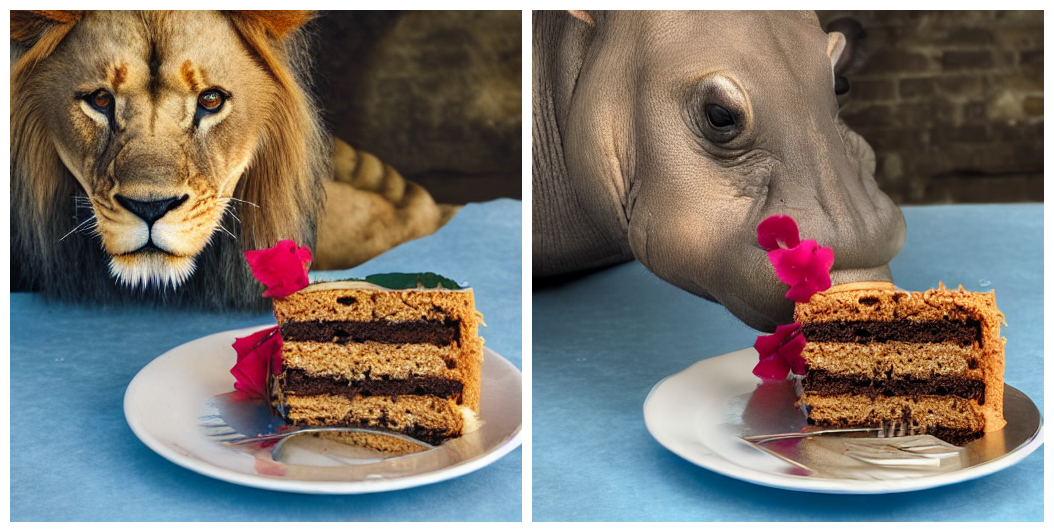

In [12]:
# Add the output of this cell to overleaf
prompt = ["A photograph of a lion eating a cake",
          "A photograph of a hippopotamus eating a cake",
          ]
pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.8, prop_steps_self=0.2)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

# Prompt-to-Prompt: Multiple-Token to Single-Token Word Swap

conv_in: Conv2d
time_proj: Timesteps
time_embedding: TimestepEmbedding
time_embedding.linear_1: Linear
time_embedding.act: SiLU
time_embedding.linear_2: Linear
down_blocks: ModuleList
down_blocks.0: CrossAttnDownBlock2D
down_blocks.0.attentions: ModuleList
down_blocks.0.attentions.0: Transformer2DModel
down_blocks.0.attentions.0.norm: GroupNorm
down_blocks.0.attentions.0.proj_in: Conv2d
down_blocks.0.attentions.0.transformer_blocks: ModuleList
down_blocks.0.attentions.0.transformer_blocks.0: BasicTransformerBlock
down_blocks.0.attentions.0.transformer_blocks.0.norm1: LayerNorm
down_blocks.0.attentions.0.transformer_blocks.0.attn1: Attention
Replacing:  Attention <class 'prompt2prompt.MyCrossAttention'>
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q: Linear
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k: Linear
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_v: Linear
down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out: ModuleList
down_blocks.0.

  0%|          | 0/51 [00:00<?, ?it/s]

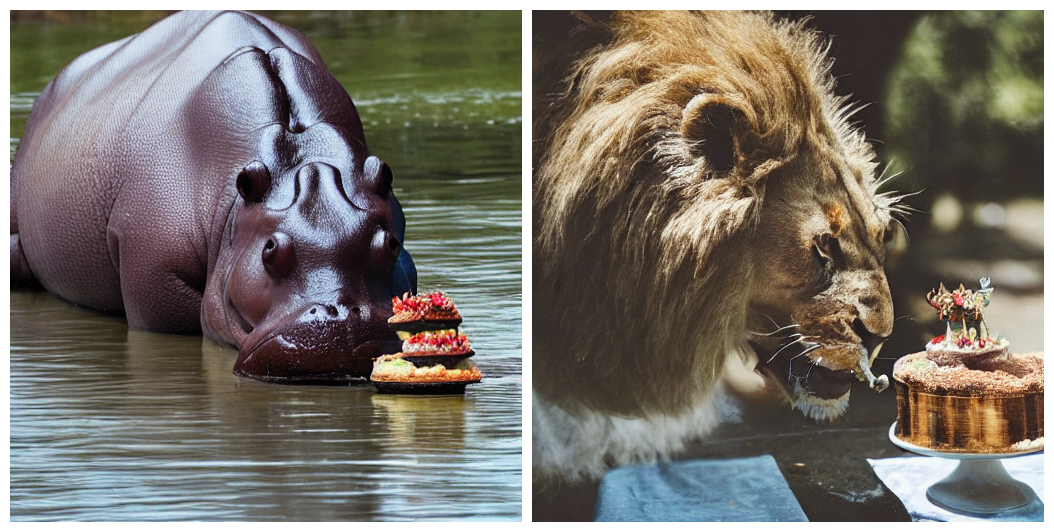

In [13]:
prompt = ["A photograph of a hippopotamus eating a cake",
          "A photograph of a lion eating a cake",
          ]
pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.8, prop_steps_self=0.2)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

In [14]:
prompt = ["A frog riding a rowboat",
          "A rabbit riding a rowboat",
          "A hedgehog riding a rowboat",
          "A raccoon riding a rowboat"
          ]
pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.9, prop_steps_self=0.1)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

Output hidden; open in https://colab.research.google.com to view.

In [15]:
prompt = ["A frog riding a rowboat",
          "A narwhal riding a rowboat",
          "A hedgehog riding a rowboat",
          "A axolotl riding a rowboat"
          ]
pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.9, prop_steps_self=0.3)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

Output hidden; open in https://colab.research.google.com to view.

In [16]:
prompt = ["A rabbit riding a rowboat",
          "A frog riding a rowboat",
          "A hedgehog riding a rowboat",
          "A raccoon riding a rowboat"
          ]
pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.7, prop_steps_self=0.3)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

Output hidden; open in https://colab.research.google.com to view.

In [17]:
prompt = ["A rabbit riding a rowboat",
          "A frog riding a rowboat",
          "A hedgehog riding a rowboat",
          "A raccoon riding a rowboat"
          ]
pipe = MyLDMPipeline(num_inference_steps, guidance_scale)
swapper = MySharedAttentionSwapper(prompt, pipe.tokenizer, prop_steps_cross=0.5, prop_steps_self=0.2)
unet_inject_attention_modules(pipe.unet, swapper)
image = pipe.generate_image_from_text(prompt, swapper)
grid_image = create_image_grid(image)
if on_colab:
    display(grid_image)
else:
    grid_image.show()

Output hidden; open in https://colab.research.google.com to view.